# Tuned CNN

## Data Loading & Train_validation_test split

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#from google.colab import drive
#drive.mount('/content/drive')
#data_root = "/content/drive/MyDrive/Sampled MRI/"
data_root = "Sampled MRI/"
groups = {"AD": 0, "MCI": 1, "NC": 2}
IMG_SIZE = (224, 224)
CHANNELS = 1

images, labels = [], []

for group, label in groups.items():
    folder = os.path.join(data_root, group)
    for fname in os.listdir(folder):
        if fname.startswith('.') or not fname.lower().endswith(".png"):
            continue
        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype("float32") / 255.0
        images.append(img)
        labels.append(label)

images = np.expand_dims(np.array(images), axis=-1)
labels = np.array(labels)
labels_cat = to_categorical(labels, num_classes=3)

# Split train/validation/test sets
X_temp, X_test, y_temp, y_test = train_test_split(images, labels_cat, test_size=0.15, stratify=labels, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (6299, 224, 224, 1), Val: (1351, 224, 224, 1), Test: (1350, 224, 224, 1)


## CNN model tuning

In [11]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    horizontal_flip=True
)
datagen.fit(X_train)

In [12]:
def model_builder(hp):
    conv1_filters = hp.Int('conv1_filters', 32, 128, step=32)
    conv2_filters = hp.Int('conv2_filters', 64, 256, step=64)
    dense_units = hp.Int('dense_units', 128, 512, step=128)
    dropout_rate = hp.Float('dropout_rate', 0.3, 0.6, step=0.1)
    lr = hp.Float('learning_rate', 1e-5, 5e-4, sampling='log')

    model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),

        Conv2D(conv1_filters, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),

        Conv2D(conv2_filters, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),

        Conv2D(conv2_filters // 2, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2),

        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [13]:
tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='cnn_tuner',
    project_name='mri_ad_classification'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

tuner.search(
    datagen.flow(X_train, y_train, batch_size=8),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Trial 20 Complete [00h 10m 09s]
val_accuracy: 0.35233160853385925

Best val_accuracy So Far: 0.784604012966156
Total elapsed time: 04h 22m 22s


In [14]:
best_hp = tuner.get_best_hyperparameters(1)[0]
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

  conv1_filters: 64
  conv2_filters: 96
  dense_units: 192
  dropout_rate: 0.2
  learning_rate: 7.35417537744718e-05


In [15]:
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    validation_data=(X_val, y_val),
    epochs=80,                      # 增加epoch充分训练
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


788/788 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.3657 - loss: 1.7032 - val_accuracy: 0.4589 - val_loss: 1.0325 - learning_rate: 7.3542e-05
Epoch 2/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.4135 - loss: 1.0663 - val_accuracy: 0.4730 - val_loss: 1.0103 - learning_rate: 7.3542e-05
Epoch 3/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.4493 - loss: 1.0334 - val_accuracy: 0.4730 - val_loss: 1.1524 - learning_rate: 7.3542e-05
Epoch 4/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4742 - loss: 1.0236 - val_accuracy: 0.5529 - val_loss: 0.9140 - learning_rate: 7.3542e-05
Epoch 5/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.4906 - loss: 0.9741 - val_accuracy: 0.5625 - val_loss: 0.8831 - learning_rate: 7.3542e-05
Epoch 6/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5360 - loss: 0.9141 - val_accuracy: 0.5796 - val_loss: 0.8835 - learning_rate: 7.3542e-05
Epoch 7/80
788/788 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accurac

## Evaluation

In [16]:
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step

Test Accuracy: 0.8355555555555556

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81       450
           1       0.86      0.87      0.87       450
           2       0.82      0.85      0.83       450

    accuracy                           0.84      1350
   macro avg       0.84      0.84      0.84      1350
weighted avg       0.84      0.84      0.84      1350


Confusion Matrix:
 [[354  35  61]
 [ 33 393  24]
 [ 41  28 381]]


## COnfusion Matrix

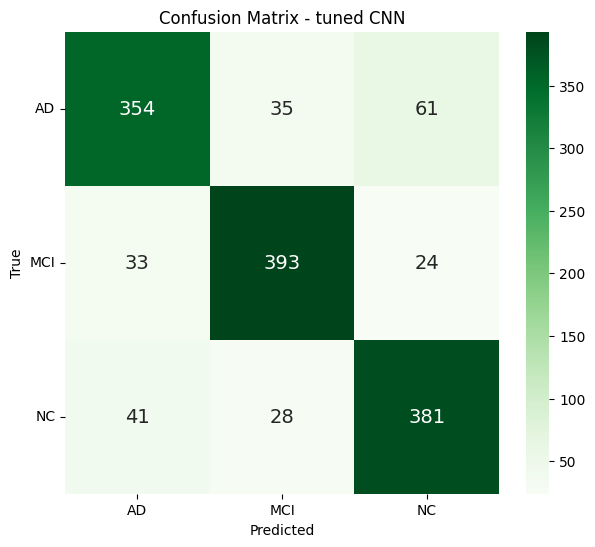

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['AD', 'MCI', 'NC']

# confusion matrix - tuned CNN
matrix_data = np.array([
    [354, 35, 61], # True AD
    [33, 393, 24],  # True MCI
    [41, 28, 381]   # True NC
])

df_cm = pd.DataFrame(matrix_data, index=classes, columns=classes)

# Create the plot
plt.figure(figsize=(7, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Greens', cbar=True, annot_kws={'size': 14})
plt.title('Confusion Matrix - tuned CNN')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.yticks(rotation=0)
plt.show()